In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm
import torch
import torch.nn as nn
import torch.optim as optim
from matplotlib.animation import FuncAnimation
import time





# =====================================================================
# 1. CONFIGURACIÓN DE GPU/CUDA
# =====================================================================
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
if device.type == 'cuda':
    print("CUDA disponible. Usando GPU para entrenamiento.")
else:
    print("CUDA no disponible. Usando CPU para entrenamiento.")

# =====================================================================
# 2. SELECCIÓN DE FUNCIÓN DE ACTIVACIÓN
# =====================================================================
ACTIVATION_TYPE = 'sin'
L_y = 1.0
L_x = 1.0

Ny = 20
Nx = 20
Nt = 20

N_grid = Nx * Ny * Nt

lamb = 0.05
class SinActivation(nn.Module):
    def forward(self, x):
        return torch.sin(x)

def get_activation():
    if ACTIVATION_TYPE == 'sin':
        return SinActivation()
    return nn.Tanh()

# Var
x = torch.linspace(0, 20, Nx, device=device)
y = torch.linspace(0, 20, Ny, device=device)
t = torch.linspace(0, 20, Nt, device=device)

Tg, Xg, Yg = torch.meshgrid(t, x, y, indexing='ij')

# Inicial
x0 = torch.linspace(0, L_x, Nx, device=device)
y0 = torch.linspace(0, L_y, Ny, device=device)

X0, Y0 = torch.meshgrid(x0, y0, indexing='ij')

# Bordes
y_norte = L_y * torch.ones((Ny*Nt,1), device=device)
y_sur = torch.zeros((Ny*Nt,1), device=device)

x_rigth = L_x * torch.ones((Nx*Nt,1), device=device)
x_left = torch.zeros((Nx*Nt,1), device=device)

Xb, Txb = torch.meshgrid(x, t, indexing='ij')
Yb, Tyb = torch.meshgrid(y, t, indexing='ij')

#tb = torch.rand((Nt,1), device=device) * T

# =====================================================================
# 3. DEFINICIÓN DEL MODELO
# =====================================================================
class PINN(nn.Module):
    def __init__(self, activation_fn):
        super(PINN, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(3, 64),
            activation_fn,
            nn.Linear(64, 64),
            activation_fn,
            nn.Linear(64, 64),
            activation_fn,
            nn.Linear(64, 64),
            activation_fn,
            nn.Linear(64, 1)
        )

    def forward(self, x):
        return self.net(x)

def build_model():
    activation_fn = get_activation()
    return PINN(activation_fn)

# =====================================================================
# 4. FUNCIÓN EDO (FÍSICA) Y CONDICIONES
# =====================================================================

def edo_func(modelo, feature):
    phi = modelo(feature)  # phi shape: (N, 1)

    dphi = torch.autograd.grad(phi, feature, grad_outputs=torch.ones_like(phi), create_graph=True)[0]
    dphi_x = dphi[:, 0]
    dphi_y = dphi[:, 1]
    dphi_t = dphi[:, 2]

    ddx_phi = torch.autograd.grad(dphi_x, feature, grad_outputs=torch.ones_like(dphi_x), create_graph=True)[0][:, 0]
    ddy_phi = torch.autograd.grad(dphi_y, feature, grad_outputs=torch.ones_like(dphi_y), create_graph=True)[0][:, 1]
    ddt_phi = torch.autograd.grad(dphi_t, feature, grad_outputs=torch.ones_like(dphi_t), create_graph=True)[0][:, 2]

    c = 0.5
    zeta = ddt_phi - (c**2) * (ddx_phi + ddy_phi)
    return (zeta**2).reshape(Nt, -1).mean(dim=1)

def condicion_inicial(modelo, x, y, x0, y0,ampl):
    """
    x0, y0: tensores de puntos espaciales
    shape: (N,1)
    """

    t = torch.zeros_like(x)
    feature0 = torch.cat([x, y, t], dim=1)
    feature0.requires_grad_(True)

    u_pred = modelo(feature0)
    radio = torch.sqrt((x-x0)**2 + (y-y0)**2)
    u_real = ampl * torch.exp(-(radio/lamb)**2)

    loss_u0 = torch.mean((u_pred - u_real) ** 2)

    # Derivada temporal
    grad_u = torch.autograd.grad(u_pred,feature0,grad_outputs=torch.ones_like(u_pred),create_graph=True)[0]

    ut_pred = grad_u[:, 2]

    u_t = 0
    loss_ut0 = torch.mean((ut_pred - u_t) ** 2)

    return loss_u0 + loss_ut0

def condicion_de_borde(modelo, x, y):

    norte = torch.cat([x, y_norte, Txb.reshape(-1,1)], dim = 1 )
    sur   = torch.cat([x, y_sur, Txb.reshape(-1,1)], dim = 1 )
    este  = torch.cat([x_left, y, Tyb.reshape(-1,1)], dim = 1 )
    oeste = torch.cat([x_rigth, y, Tyb.reshape(-1,1)], dim = 1 )

    norte_mol=modelo(norte)
    sur_mol=modelo(sur)
    este_mol=modelo(este)
    oeste_mol=modelo(oeste)

    L_bc = torch.mean(norte_mol**2) + torch.mean(sur_mol**2) + torch.mean(este_mol**2) + torch.mean(oeste_mol**2)
    return L_bc

def perdida(modelo, feature, eps=1.0):
    L_t = edo_func(modelo, feature)
    with torch.no_grad():
        W_t = torch.exp(-eps * (torch.cumsum(L_t, dim=0) - L_t))
             # peso causal

    zeta_nau = torch.sum(W_t * L_t) / torch.sum(W_t)
    zeta_inicial = condicion_inicial(modelo, X0.reshape(-1,1), Y0.reshape(-1,1), L_x/2, L_y/2, 4.0)
    zeta_borde = condicion_de_borde(modelo, Xb.reshape(-1,1), Yb.reshape(-1,1))
    return zeta_nau + zeta_inicial + zeta_borde

# =====================================================================
# 5. PASO DE ENTRENAMIENTO Y OPTIMIZACIÓN
# =====================================================================
def train_step(modelo, feature, optimi):
    optimi.zero_grad()
    loss = perdida(modelo, feature)
    loss.backward()
    optimi.step()
    return loss

def optimizar(modelo, feature, N=40000):
    optimi = optim.Adam(modelo.parameters(), lr =0.00001)
    err = []

    # OPTIMIZACIÓN: Convertir entradas a tensores de PyTorch antes del bucle
    feature_tf = torch.tensor(feature, dtype=torch.float32, device=device).requires_grad_(True)

    for i in range(N):
        loss = train_step(modelo, feature_tf, optimi)
        loss_val = loss.item()
        if i % 100 == 0:
            print("Entrenamiento :", i, " | Perdida :", loss_val)
        err.append(loss_val)
    return err

# =====================================================================
# 6. PREPROCESAMIENTO DE MALLA VECTORIZADO
# =====================================================================
inicio = time.time()

feature = torch.stack([Xg.reshape(-1), Yg.reshape(-1), Tg.reshape(-1)], dim=1)

model = build_model().to(device)

fin = time.time()
print("Tiempo antes del entrenamiento:", fin - inicio, "segundos")

# =====================================================================
# 7. ENTRENAMIENTO
# =====================================================================
inicio = time.time()
opt = optimizar(model, feature)
fin = time.time()
print("Tiempo del entrenamiento:", fin - inicio, "segundos")

plt.plot(range(len(opt)), opt)
plt.xlabel("Iteración")
plt.ylabel("Pérdida")
plt.title("Evolución de la pérdida")
plt.show()




CUDA disponible. Usando GPU para entrenamiento.
Tiempo antes del entrenamiento: 0.0016677379608154297 segundos
Entrenamiento : 0  | Perdida : 0.18647435307502747


/tmp/ipykernel_1641/1734275468.py:183: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  feature_tf = torch.tensor(feature, dtype=torch.float32, device=device).requires_grad_(True)


Entrenamiento : 100  | Perdida : 0.13148096203804016
Entrenamiento : 200  | Perdida : 0.09674718976020813
Entrenamiento : 300  | Perdida : 0.07609325647354126
Entrenamiento : 400  | Perdida : 0.06497456878423691
Entrenamiento : 500  | Perdida : 0.05941702425479889
Entrenamiento : 600  | Perdida : 0.05669017136096954
Entrenamiento : 700  | Perdida : 0.05532526969909668
Entrenamiento : 800  | Perdida : 0.05461639538407326
Entrenamiento : 900  | Perdida : 0.054231442511081696
Entrenamiento : 1000  | Perdida : 0.054011255502700806
Entrenamiento : 1100  | Perdida : 0.053877342492341995
Entrenamiento : 1200  | Perdida : 0.053790006786584854
Entrenamiento : 1300  | Perdida : 0.053728848695755005
Entrenamiento : 1400  | Perdida : 0.053683195263147354
Entrenamiento : 1500  | Perdida : 0.05364730581641197
Entrenamiento : 1600  | Perdida : 0.05361800268292427
Entrenamiento : 1700  | Perdida : 0.053593434393405914
Entrenamiento : 1800  | Perdida : 0.053572431206703186
Entrenamiento : 1900  | Perdi

/tmp/ipykernel_1641/729133667.py:8: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  feature_tf = torch.tensor(feature, dtype=torch.float32, device=device)


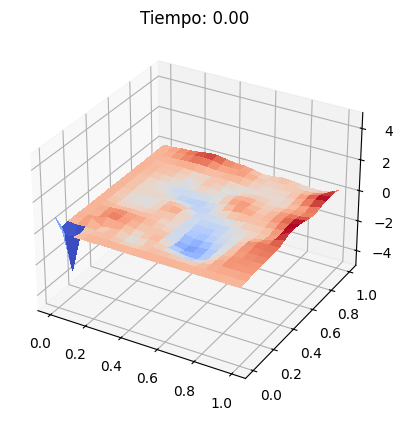

In [6]:
# =====================================================================
# 8. VISUALIZACIÓN / ANIMACIÓN
# =====================================================================
x = np.linspace(0,L_x,Nx)
y = np.linspace(0,L_y,Ny)
model.eval()
with torch.no_grad():
    feature_tf = torch.tensor(feature, dtype=torch.float32, device=device)
    dats_fijo = model(feature_tf).cpu().numpy().reshape((Nx, Ny, Nt))

xx, yy = np.meshgrid(x, y)

fig, axl = plt.subplots(subplot_kw=dict(projection='3d'))

def actualizarL(i):
    axl.clear()
    axl.set_zlim(-5, 5)
    axl.plot_surface(xx, yy, dats_fijo[i, :, :], cmap=cm.coolwarm, linewidth=0, antialiased=False)
    axl.set_title(f"Tiempo: {t[i]:.2f}")

chu = FuncAnimation(fig, actualizarL, frames=Nt, interval=100)
chu.save(f'ecuacion de onda_tf3_{ACTIVATION_TYPE}.gif')

CUDA disponible. Usando GPU para entrenamiento.
Tiempo antes del entrenamiento: 0.004029750823974609 segundos
Entrenamiento : 0  | Perdida : 0.08218906074762344
Entrenamiento : 100  | Perdida : 0.03955506533384323
Entrenamiento : 200  | Perdida : 0.03935558721423149
Entrenamiento : 300  | Perdida : 0.03152479976415634
Entrenamiento : 400  | Perdida : 0.03659716993570328
Entrenamiento : 500  | Perdida : 0.025475136935710907
Entrenamiento : 600  | Perdida : 0.005282972473651171
Entrenamiento : 700  | Perdida : 0.037049587815999985
Entrenamiento : 800  | Perdida : 0.0727846771478653
Entrenamiento : 900  | Perdida : 0.0210200734436512
Entrenamiento : 1000  | Perdida : 0.07390221208333969
Entrenamiento : 1100  | Perdida : 0.014581340365111828
Entrenamiento : 1200  | Perdida : 0.029116099700331688
Entrenamiento : 1300  | Perdida : 0.06854452192783356
Entrenamiento : 1400  | Perdida : 0.10533197969198227
Entrenamiento : 1500  | Perdida : 0.02265315130352974
Entrenamiento : 1600  | Perdida : 0

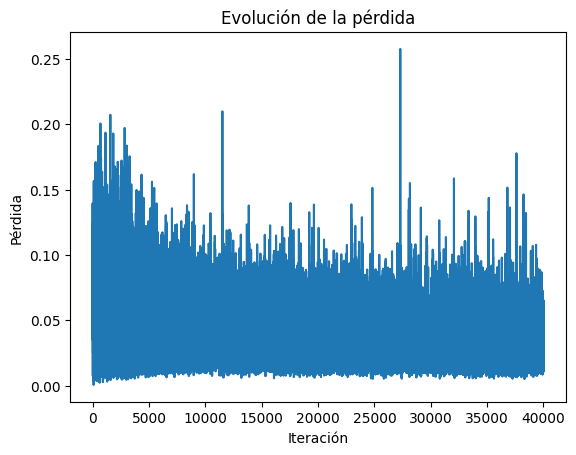

In [24]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm
import torch
import torch.nn as nn
import torch.optim as optim
from matplotlib.animation import FuncAnimation
import time





# =====================================================================
# 1. CONFIGURACIÓN DE GPU/CUDA
# =====================================================================
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
if device.type == 'cuda':
    print("CUDA disponible. Usando GPU para entrenamiento.")
else:
    print("CUDA no disponible. Usando CPU para entrenamiento.")

# =====================================================================
# 2. SELECCIÓN DE FUNCIÓN DE ACTIVACIÓN Y PARÁMETROS DEL DOMINIO
# =====================================================================
ACTIVATION_TYPE = 'sin'
L_y = 1.0
L_x = 1.0
T   = 1.0

Ny = 20
Nx = 20
Nt = 20

N_grid = Nx * Ny * Nt   # usado solo para la malla de EVALUACIÓN/plot (cell 1), no para entrenar

lamb = 0.05
class SinActivation(nn.Module):
    def forward(self, x):
        return torch.sin(x)

def get_activation():
    if ACTIVATION_TYPE == 'sin':
        return SinActivation()
    return nn.Tanh()

# =====================================================================
# 3. DEFINICIÓN DEL MODELO
# =====================================================================
class PINN(nn.Module):
    def __init__(self, activation_fn):
        super(PINN, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(3, 64),
            activation_fn,
            nn.Linear(64, 64),
            activation_fn,
            nn.Linear(64, 64),
            activation_fn,
            nn.Linear(64, 64),
            activation_fn,
            nn.Linear(64, 1)
        )

    def forward(self, x):
        return self.net(x)

def build_model():
    activation_fn = get_activation()
    return PINN(activation_fn)

# =====================================================================
# 4. MUESTREO ALEATORIO DE PUNTOS DE COLOCACIÓN (RESAMPLING)
# =====================================================================
# En vez de una malla fija (la que usaba meshgrid + se reutilizaba en las
# 40000 iteraciones), generamos puntos nuevos cada vez que se llama a estas
# funciones. Esto evita que la red sobreajuste a una grilla específica y
# le da, en promedio, cobertura sobre todo el dominio continuo en vez de
# solo Nx*Ny*Nt puntos fijos.

def muestrear_interior(N, device):
    """N puntos aleatorios (x,y,t) en el interior del dominio, para el residuo de la PDE."""
    x_f = torch.rand(N, 1, device=device) * L_x
    y_f = torch.rand(N, 1, device=device) * L_y
    t_f = torch.rand(N, 1, device=device) * T
    feature = torch.cat([x_f, y_f, t_f], dim=1)
    feature.requires_grad_(True)
    return feature

def muestrear_inicial(N, device):
    """N puntos aleatorios (x,y) en t=0, para la condición inicial."""
    x0 = torch.rand(N, 1, device=device) * L_x
    y0 = torch.rand(N, 1, device=device) * L_y
    return x0, y0

def muestrear_borde(N, device):
    """N puntos aleatorios por cada uno de los 4 lados del dominio (norte, sur, este, oeste)."""
    # Norte (y=L_y) y Sur (y=0): x y t aleatorios
    x_ns = torch.rand(N, 1, device=device) * L_x
    t_ns = torch.rand(N, 1, device=device) * T
    norte = torch.cat([x_ns, torch.full_like(x_ns, L_y), t_ns], dim=1)
    sur   = torch.cat([x_ns, torch.zeros_like(x_ns), t_ns], dim=1)

    # Este (x=0) y Oeste (x=L_x): y y t aleatorios
    y_eo = torch.rand(N, 1, device=device) * L_y
    t_eo = torch.rand(N, 1, device=device) * T
    este  = torch.cat([torch.zeros_like(y_eo), y_eo, t_eo], dim=1)
    oeste = torch.cat([torch.full_like(y_eo, L_x), y_eo, t_eo], dim=1)

    return norte, sur, este, oeste

# =====================================================================
# 5. FUNCIÓN EDO (FÍSICA) Y CONDICIONES
# =====================================================================

def edo_func(modelo, feature):
    phi = modelo(feature)  # phi shape: (N, 1)

    dphi = torch.autograd.grad(phi, feature, grad_outputs=torch.ones_like(phi), create_graph=True)[0]
    dphi_x = dphi[:, 0]
    dphi_y = dphi[:, 1]
    dphi_t = dphi[:, 2]

    ddx_phi = torch.autograd.grad(dphi_x, feature, grad_outputs=torch.ones_like(dphi_x), create_graph=True)[0][:, 0]
    ddy_phi = torch.autograd.grad(dphi_y, feature, grad_outputs=torch.ones_like(dphi_y), create_graph=True)[0][:, 1]
    ddt_phi = torch.autograd.grad(dphi_t, feature, grad_outputs=torch.ones_like(dphi_t), create_graph=True)[0][:, 2]

    c = 0.5
    zeta = ddt_phi - c * (ddx_phi + ddy_phi)
    return torch.mean(zeta**2)

def condicion_inicial(modelo, x, y, x0, y0, ampl):
    """
    x, y: tensores de puntos espaciales muestreados aleatoriamente
    shape: (N,1)
    """

    t0 = torch.zeros_like(x)
    feature0 = torch.cat([x, y, t0], dim=1)
    feature0.requires_grad_(True)

    u_pred = modelo(feature0)
    radio = torch.sqrt((x-x0)**2 + (y-y0)**2)
    u_real = ampl * torch.exp(-(radio/lamb)**2)

    loss_u0 = torch.mean((u_pred - u_real) ** 2)

    # Derivada temporal
    grad_u = torch.autograd.grad(u_pred, feature0, grad_outputs=torch.ones_like(u_pred), create_graph=True)[0]

    ut_pred = grad_u[:, 2]

    u_t = 0
    loss_ut0 = torch.mean((ut_pred - u_t) ** 2)

    return loss_u0 + loss_ut0

def condicion_de_borde(modelo, norte, sur, este, oeste):

    norte_mol = modelo(norte)
    sur_mol = modelo(sur)
    este_mol = modelo(este)
    oeste_mol = modelo(oeste)

    L_bc = torch.mean(norte_mol**2) + torch.mean(sur_mol**2) + torch.mean(este_mol**2) + torch.mean(oeste_mol**2)
    return L_bc

def perdida(modelo, N_pde, N_ic, N_bc):
    feature_pde = muestrear_interior(N_pde, device)
    zeta_nau = edo_func(modelo, feature_pde)

    x_ic, y_ic = muestrear_inicial(N_ic, device)
    zeta_inicial = condicion_inicial(modelo, x_ic, y_ic, L_x/2, L_y/2, 4.0)

    norte, sur, este, oeste = muestrear_borde(N_bc, device)
    zeta_borde = condicion_de_borde(modelo, norte, sur, este, oeste)

    return zeta_nau + zeta_inicial + zeta_borde

# =====================================================================
# 6. PASO DE ENTRENAMIENTO Y OPTIMIZACIÓN
# =====================================================================
def train_step(modelo, optimi, N_pde, N_ic, N_bc):
    optimi.zero_grad()
    loss = perdida(modelo, N_pde, N_ic, N_bc)
    loss.backward()
    optimi.step()
    return loss

def optimizar(modelo, N=40000, N_pde=4000, N_ic=400, N_bc=400):
    """
    N_pde: puntos interiores nuevos por iteración (residuo PDE)
    N_ic : puntos nuevos por iteración en t=0 (condición inicial)
    N_bc : puntos nuevos por iteración POR CADA lado del borde
    Todos se resamplean en cada llamada a train_step -> cada iteración
    ve un set de puntos de colocación distinto.
    """
    optimi = optim.Adam(modelo.parameters(), lr=0.003)
    err = []

    for i in range(N):
        loss = train_step(modelo, optimi, N_pde, N_ic, N_bc)
        loss_val = loss.item()
        if i % 100 == 0:
            print("Entrenamiento :", i, " | Perdida :", loss_val)
        err.append(loss_val)
    return err

# =====================================================================
# 7. MALLA DE EVALUACIÓN (solo para graficar en la celda de visualización)
# =====================================================================
inicio = time.time()

x = torch.linspace(0, L_x, Nx, device=device)
y = torch.linspace(0, L_y, Ny, device=device)
t = torch.linspace(0, T, Nt, device=device)

Tg, Xg, Yg = torch.meshgrid(t, x, y, indexing='ij')
feature = torch.stack([Xg.reshape(-1), Yg.reshape(-1), Tg.reshape(-1)], dim=1)

model = build_model().to(device)

fin = time.time()
print("Tiempo antes del entrenamiento:", fin - inicio, "segundos")

# =====================================================================
# 8. ENTRENAMIENTO
# =====================================================================
inicio = time.time()
opt = optimizar(model, N=40000, N_pde=4000, N_ic=400, N_bc=400)
fin = time.time()
print("Tiempo del entrenamiento:", fin - inicio, "segundos")

plt.plot(range(len(opt)), opt)
plt.xlabel("Iteración")
plt.ylabel("Pérdida")
plt.title("Evolución de la pérdida")
plt.show()


/tmp/ipykernel_1641/1171695326.py:7: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  feature_tf = torch.tensor(feature, dtype=torch.float32, device=device)


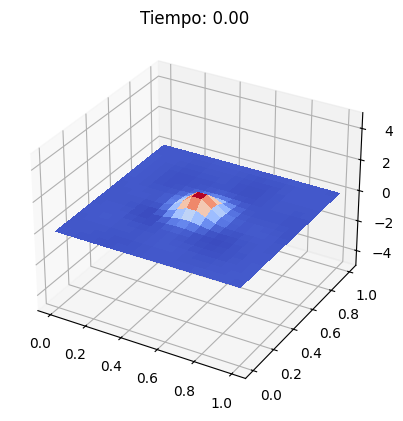

In [47]:
x = np.linspace(0,L_x,Nx)
y = np.linspace(0,L_y,Ny)
t = torch.linspace(0, T, Nt, device=device)

model.eval()
with torch.no_grad():
    feature_tf = torch.tensor(feature, dtype=torch.float32, device=device)
    dats_sample = model(feature_tf).cpu().numpy().reshape((Nx, Ny, Nt))

xx, yy = np.meshgrid(x, y)

fig, axl = plt.subplots(subplot_kw=dict(projection='3d'))

def actualizarL(i):
    axl.clear()
    axl.set_zlim(-5, 5)
    axl.plot_surface(xx, yy, dats_sample[i, :, :], cmap=cm.coolwarm, linewidth=0, antialiased=False)
    axl.set_title(f"Tiempo: {t[i]:.2f}")

chu = FuncAnimation(fig, actualizarL, frames=Nt, interval=100)
chu.save(f'ecuacion de onda_tf3_sampling_{ACTIVATION_TYPE}.gif')

## Real

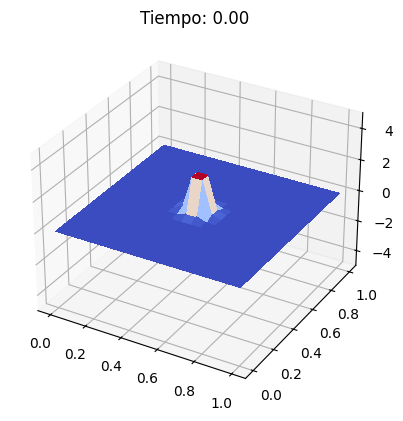

In [41]:
x = np.linspace(0,L_x,Nt)
y = np.linspace(0,L_y,Nt)
xx, yy = np.meshgrid(x, y)
radio = np.sqrt((xx-0.5)**2 + (yy-0.5)**2)
u_real = np.zeros((Nt,len(radio),len(radio)))
t_real = np.linspace(0,T, Nt)
for ide_t,t in enumerate(t_real):
  u_real[ide_t,:,:] = 4 * np.exp(-(((radio) - 0.5 * t)/0.05)**2)

fig, axl = plt.subplots(subplot_kw=dict(projection='3d'))

def actualizarL(i):
    axl.clear()
    axl.set_zlim(-5, 5)
    axl.plot_surface(xx, yy, u_real[i, :, :], cmap=cm.coolwarm, linewidth=0, antialiased=False)
    axl.set_title(f"Tiempo: {t_real[i]:.2f}")

chu = FuncAnimation(fig, actualizarL, frames=Nt, interval=100)
chu.save(f'ecuacion de onda_tf3_real.gif')

## Comparación

In [48]:
xx, yy = np.meshgrid(x, y)
radio = np.sqrt((xx-0.5)**2 + (yy-0.5)**2)
u_real = np.zeros((Nt,len(radio),len(radio)))

MSE_fijo = np.zeros(Nt)
MSE_sample = np.zeros(Nt)

for ide_t,t in enumerate(np.linspace(0,T, Nt)):
  u_real[ide_t,:,:] = 4 * np.exp(-((radio - 0.5 * t)/0.05)**2)

  MSE_fijo[ide_t] = np.mean((dats_fijo[ide_t,:,:] - u_real[ide_t,:,:])**2)
  MSE_sample[ide_t] = np.mean((dats_sample[ide_t,:,:] - u_real[ide_t,:,:])**2)

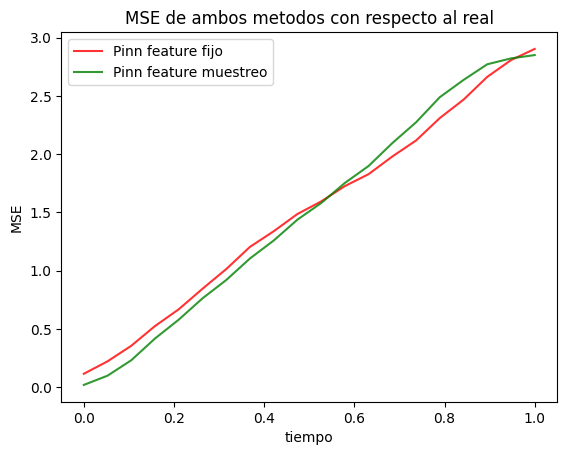

In [49]:
plt.plot(np.linspace(0,T,Nt),MSE_fijo,"-r",label="Pinn feature fijo",alpha=0.8)
plt.plot(np.linspace(0,T,Nt),MSE_sample,"-g",label="Pinn feature muestreo",alpha=0.8)

plt.title("MSE de ambos metodos con respecto al real")
plt.xlabel("tiempo"); plt.ylabel("MSE")
plt.legend()
plt.show()

